Shape: (618, 4)
     API   density  viscosity   class
0  34.89    0.8496      13.00   light
1  29.50    0.8783      29.00  medium
2  30.20    0.8743      13.00  medium
3  11.00  992.1200       0.42   heavy
4  10.90    0.9930  485500.00   heavy


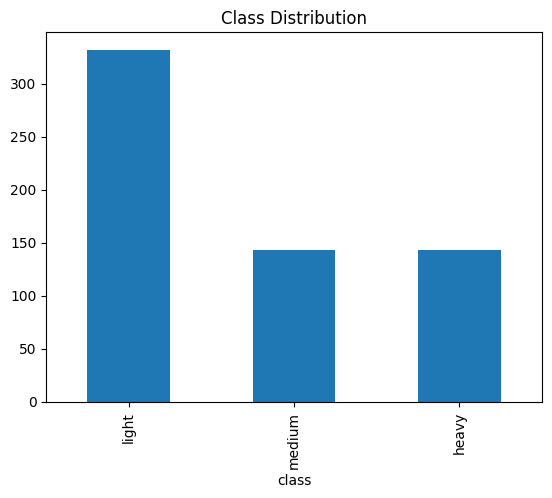

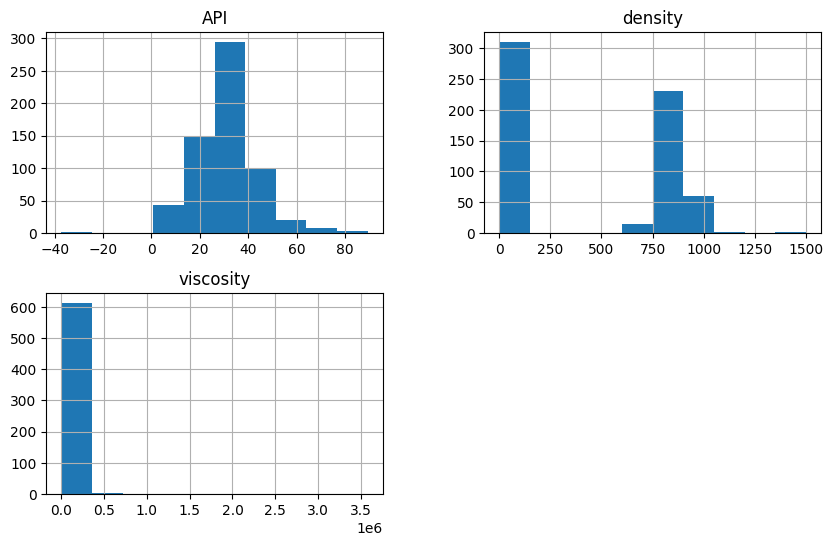

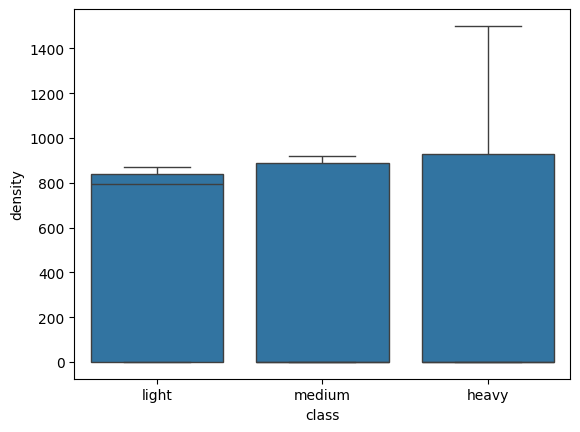

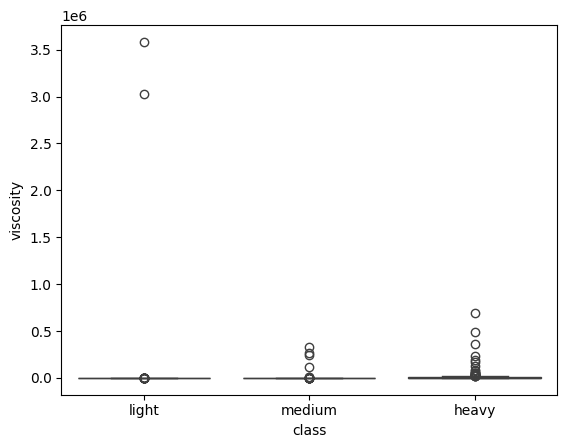

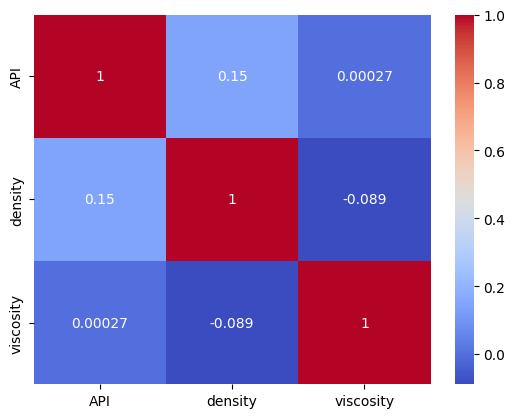

              API     density     viscosity
class                                      
heavy   15.510350  274.146889  22207.138274
light   39.897500  496.354437  19913.427399
medium  27.262797  418.393557   6804.375084


In [3]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Настройки
# =========================
folder = "oil"   # путь к папке
TARGET_TEMP = 15

data = []


# =========================
# Функции (те же, что в модели)
# =========================
def get_closest_value(items, value_key):
    closest_item = None
    min_diff = float("inf")

    for item in items:
        temp = item.get("ref_temp", {}).get("value")
        if temp is None:
            continue

        diff = abs(temp - TARGET_TEMP)

        if diff < min_diff:
            min_diff = diff
            closest_item = item

    if closest_item:
        return closest_item[value_key]["value"]

    return None


def get_closest_viscosity(items):
    closest_item = None
    min_diff = float("inf")

    for item in items:
        temp = item.get("ref_temp", {}).get("value")
        if temp is None:
            continue

        diff = abs(temp - TARGET_TEMP)

        if diff < min_diff:
            min_diff = diff
            closest_item = item

    if closest_item:
        value = closest_item["viscosity"]["value"]
        unit = closest_item["viscosity"].get("unit")

        if unit == "Pa.s":
            value *= 1000

        return value

    return None


def classify_oil(api):
    if api > 31:
        return "light"
    elif api > 22:
        return "medium"
    else:
        return "heavy"


# =========================
# Сбор данных
# =========================
for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".json"):
            with open(os.path.join(root, file)) as f:
                oil = json.load(f)

                try:
                    api = oil["metadata"].get("API")

                    sample = oil["sub_samples"][0]
                    phys = sample.get("physical_properties", {})

                    densities = phys.get("densities", [])
                    viscosities = phys.get("dynamic_viscosities", [])

                    density = get_closest_value(densities, "density")
                    viscosity = get_closest_viscosity(viscosities)

                    if api and density and viscosity:
                        data.append({
                            "API": api,
                            "density": density,
                            "viscosity": viscosity,
                            "class": classify_oil(api)
                        })

                except:
                    continue


# =========================
# DataFrame
# =========================
df = pd.DataFrame(data)

print("Shape:", df.shape)
print(df.head())


# =========================
# 1. Классы
# =========================
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()


# =========================
# 2. Гистограммы
# =========================
df.hist(figsize=(10,6))
plt.show()


# =========================
# 3. Boxplot
# =========================
sns.boxplot(x="class", y="density", data=df)
plt.show()

sns.boxplot(x="class", y="viscosity", data=df)
plt.show()


# =========================
# 4. Корреляция
# =========================
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


# =========================
# 5. Средние значения
# =========================
print(df.groupby("class").mean(numeric_only=True))

